# TS4 - Primeras nociones de estimación espectral

## Cano Aylin


En este trabajo se busca estimar dos parámetros de una senoidal con ruido: su amplitud $a_1$ y su frecuencia $\Omega_1$. Para esto se diseñan dos estimadores:

- Estimador de amplitud:
$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

que mide el módulo del espectro de la señal ventaneada en la frecuencia $\Omega_0$.

- Estimador de frecuencia:

$$\hat{\Omega}_1^i = \arg\max_{f} \{|X_w^i(\Omega)|\}$$

que busca la frecuencia donde el espectro tiene su valor máximo.

Estos estimadores se calcularon aplicando 4 ventanas distintas $w_i$: rectangular, flat-top, Blackman-Harris y Hamming, antes de la FFT y para cada una se evaluo 

- Sesgo ($s_a$) mide qué tan lejos está, en promedio, la estimación del valor real.
- Varianza ($v_a$) mide qué tan separados son los resultados entre sí.

Todo esto se repitió para dos niveles de ruido SNR=10 dB y SNR=3 dB.

### Generación de la señal

Se genera la señal $x(n) = a_0 \cdot \text{sen}(\Omega_1 \cdot n) + n_a(n)$, donde:

- $a_0 = \sqrt{2}$ es para que la potencia de la senoidal sea 1 W
- $\Omega_1 = \Omega_0 + f_r \cdot \dfrac{2\pi}{N}$, con $\Omega_0 = \pi/2$ fijo y $f_r \sim \mathcal{U}(-2, 2)$ aleatorio

Como $f_r$ es aleatorio, la frecuencia real $\Omega_1$ queda "corrida" un poco respecto a $\Omega_0$ en cada una de las $R=200$ realizaciones lo cual genera que la señal casi nunca cae exactamente en un bin de la FFT.

In [1]:
#importacion de modulos
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

#Definiciones de la señal
a0 = np.sqrt(2)
N = 1000
fs = 1000
Ps = 1
R = 200

fr = np.random.uniform(-2, 2, R)

nn = np.arange(N)
nn = np.reshape(nn, (N, 1))

om0 = (np.pi / 2) * np.ones((1, R))
om1 = om0 + fr * 2 * np.pi / N

xx = om1 * nn

Se armo el vector de frecuencias en Hz correspondiente a los bins de la FFT. Solo la mitad, y se calcula la frecuencia real $\Omega_1$ de cada realización, expresada en Hz, para poder comparar más adelante contra las estimaciones $\hat{\Omega}_1$.

In [2]:
#Vector de frecuencias y valor real de referencia
ff_vec = np.fft.fftfreq(N, 1/fs)
ff_vec = ff_vec[:N//2]

f1_real = om1 * fs / (2*np.pi)  #frecuencia real de cada realización, en Hz

Antes de calcular la FFT, la señal se multiplica por una ventana $w_i(n)$ que "recorta" un pedazo finito de la señal de $N$ muestras. Multiplicar en el tiempo equivale a convolucionar en frecuencia. Por eso el espectro de la señal ventaneada no es un pico angosto y limpio, sino que tiene:

- Un lóbulo principal, con cierto ancho.
- Lóbulos secundarios, que esparcen energía hacia las frecuencias de los costados (desparramo espectral).

Cada ventana tiene una forma distinta, y por lo tanto un ancho de lóbulo y un nivel de desparramo distinto.

Como el estimador $\hat{a}_1$ mide la energía solo en un bin fijo ($\Omega_0$), si esa energía está repartida entre varios bins vecinos (lóbulo ancho) en vez de estar concentrada en uno solo, el estimador termina viendo menos energía de la que realmente hay. Esto genera un sesgo negativo, que es más grande cuanto más ancho es el lóbulo principal de la ventana.

El estimador de frecuencia $\hat{\Omega}_1 = \arg\max_f\{|X_w(\Omega)|\}$ busca en qué frecuencia el espectro tiene su valor maximo.

Con un lóbulo principal ancho, ese pico queda más aplanado, y varios bins cercanos tienen valores parecidos entre sí. Entonces, pequeñas variaciones de ruido entre realizaciones pueden hacer que el bin "ganador" cambie de uno a otro. Esto hace que la varianza del estimador de frecuencia sea mayor con ventanas de lóbulo ancho, como la flat-top.

Con una ventana de lóbulo angosto, como la rectangular, pasa al reves. El pico es más notorio y fácil de ubicar con mayor precisión, pero a cambio tiene más desparramo y más sesgo en el estimador de amplitud.

significa entonces que entre el ancho del lóbulo principal y el nivel de desparramo hay que elegir. No se puede tener lo mejor de las dos cosas al mismo tiempo ya que mejorar una empeora la otra.

#### Cálculo de los estimadores para las 4 ventanas

Se armó una función que, para un SNR dado, genera el ruido y calcula $\hat{a}_1$ y $\hat{\Omega}_1$ con su sesgo y varianza para las 4 ventanas, rectangular, flat-top, Blackman-Harris y Hamming.

In [3]:
# Función que calcula todo para un SNR dado
def calcular_estimadores(SNR):

    # ruido, según el SNR que le pasemos
    Pr = Ps / (10**(SNR/10))
    sigma = np.sqrt(Pr)
    n_a = np.random.normal(0, sigma, (N, R))
    yy = a0 * np.sin(xx) + n_a

    #Rectangular
    w_rect = windows.boxcar(N)
    w_rect = np.reshape(w_rect, (N, 1))
    yy_rect = yy * w_rect
    YY_rect = np.fft.fft(yy_rect, axis=0)
    YY_mod_rect = np.abs(YY_rect[:N//2, :]) / (N/2)

    a1_rect = YY_mod_rect[N//4, :]
    indice_max_rect = np.argmax(YY_mod_rect, axis=0)
    f1_rect = ff_vec[indice_max_rect]

    media_a1_rect = np.mean(a1_rect)
    sesgo_a1_rect = media_a1_rect - a0
    varianza_a1_rect = np.mean((a1_rect - media_a1_rect)**2)

    media_f1_rect = np.mean(f1_rect)
    sesgo_f1_rect = np.mean(f1_rect - f1_real)
    varianza_f1_rect = np.mean((f1_rect - media_f1_rect)**2)

    #Flat top
    w_flattop = windows.flattop(N)
    w_flattop = np.reshape(w_flattop, (N, 1))
    yy_flattop = yy * w_flattop
    YY_flattop = np.fft.fft(yy_flattop, axis=0)
    YY_mod_flattop = np.abs(YY_flattop[:N//2, :]) / (N/2)

    a1_flattop = YY_mod_flattop[N//4, :]
    indice_max_flattop = np.argmax(YY_mod_flattop, axis=0)
    f1_flattop = ff_vec[indice_max_flattop]

    media_a1_flattop = np.mean(a1_flattop)
    sesgo_a1_flattop = media_a1_flattop - a0
    varianza_a1_flattop = np.mean((a1_flattop - media_a1_flattop)**2)

    media_f1_flattop = np.mean(f1_flattop)
    sesgo_f1_flattop = np.mean(f1_flattop - f1_real)
    varianza_f1_flattop = np.mean((f1_flattop - media_f1_flattop)**2)

    #Blackman Harris
    w_bh = windows.blackmanharris(N)
    w_bh = np.reshape(w_bh, (N, 1))
    yy_bh = yy * w_bh
    YY_bh = np.fft.fft(yy_bh, axis=0)
    YY_mod_bh = np.abs(YY_bh[:N//2, :]) / (N/2)

    a1_bh = YY_mod_bh[N//4, :]
    indice_max_bh = np.argmax(YY_mod_bh, axis=0)
    f1_bh = ff_vec[indice_max_bh]

    media_a1_bh = np.mean(a1_bh)
    sesgo_a1_bh = media_a1_bh - a0
    varianza_a1_bh = np.mean((a1_bh - media_a1_bh)**2)

    media_f1_bh = np.mean(f1_bh)
    sesgo_f1_bh = np.mean(f1_bh - f1_real)
    varianza_f1_bh = np.mean((f1_bh - media_f1_bh)**2)

    #Hamming
    w_hamming = windows.hamming(N)
    w_hamming = np.reshape(w_hamming, (N, 1))
    yy_hamming = yy * w_hamming
    YY_hamming = np.fft.fft(yy_hamming, axis=0)
    YY_mod_hamming = np.abs(YY_hamming[:N//2, :]) / (N/2)

    a1_hamming = YY_mod_hamming[N//4, :]
    indice_max_hamming = np.argmax(YY_mod_hamming, axis=0)
    f1_hamming = ff_vec[indice_max_hamming]

    media_a1_hamming = np.mean(a1_hamming)
    sesgo_a1_hamming = media_a1_hamming - a0
    varianza_a1_hamming = np.mean((a1_hamming - media_a1_hamming)**2)

    media_f1_hamming = np.mean(f1_hamming)
    sesgo_f1_hamming = np.mean(f1_hamming - f1_real)
    varianza_f1_hamming = np.mean((f1_hamming - media_f1_hamming)**2)

    return (yy_rect, a1_rect, f1_rect, sesgo_a1_rect, varianza_a1_rect, sesgo_f1_rect, varianza_f1_rect,
            yy_flattop, a1_flattop, f1_flattop, sesgo_a1_flattop, varianza_a1_flattop, sesgo_f1_flattop, varianza_f1_flattop,
            yy_bh, a1_bh, f1_bh, sesgo_a1_bh, varianza_a1_bh, sesgo_f1_bh, varianza_f1_bh,
            yy_hamming, a1_hamming, f1_hamming, sesgo_a1_hamming, varianza_a1_hamming, sesgo_f1_hamming, varianza_f1_hamming)

Llame a la funcion, una vez con SNR = 10 dB y otra con SNR = 3 dB, guardando cada resultado con nombres diferentes para no pisar los valores entre sí

In [5]:
#Llamo a la función para SNR=10 dB
(yy_rect_10db, a1_rect_10db, f1_rect_10db, sesgo_a1_rect_10db, varianza_a1_rect_10db, sesgo_f1_rect_10db, varianza_f1_rect_10db,
 yy_flattop_10db, a1_flattop_10db, f1_flattop_10db, sesgo_a1_flattop_10db, varianza_a1_flattop_10db, sesgo_f1_flattop_10db, varianza_f1_flattop_10db,
 yy_bh_10db, a1_bh_10db, f1_bh_10db, sesgo_a1_bh_10db, varianza_a1_bh_10db, sesgo_f1_bh_10db, varianza_f1_bh_10db,
 yy_hamming_10db, a1_hamming_10db, f1_hamming_10db, sesgo_a1_hamming_10db, varianza_a1_hamming_10db, sesgo_f1_hamming_10db, varianza_f1_hamming_10db
 ) = calcular_estimadores(10)

#Llamo a la función para SNR=3 dB
(yy_rect_3db, a1_rect_3db, f1_rect_3db, sesgo_a1_rect_3db, varianza_a1_rect_3db, sesgo_f1_rect_3db, varianza_f1_rect_3db,
 yy_flattop_3db, a1_flattop_3db, f1_flattop_3db, sesgo_a1_flattop_3db, varianza_a1_flattop_3db, sesgo_f1_flattop_3db, varianza_f1_flattop_3db,
 yy_bh_3db, a1_bh_3db, f1_bh_3db, sesgo_a1_bh_3db, varianza_a1_bh_3db, sesgo_f1_bh_3db, varianza_f1_bh_3db,
 yy_hamming_3db, a1_hamming_3db, f1_hamming_3db, sesgo_a1_hamming_3db, varianza_a1_hamming_3db, sesgo_f1_hamming_3db, varianza_f1_hamming_3db
 ) = calcular_estimadores(3)

#### Histogramas de las 4 ventanas juntas

Para cada SNR, se grafican en un mismo histograma los resultados de las 4 ventanas, tanto para el estimador de amplitud como para el de frecuencia. Esto permite comparar visualmente cómo cada ventana distribuye sus estimaciones alrededor del valor real.

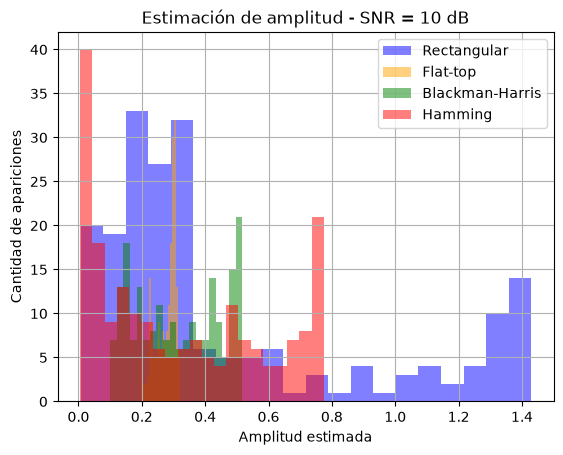

In [9]:
#Histograma de amplitud para las 4 ventanas juntas con SNR=10 dB
plt.figure()
plt.hist(a1_rect_10db, bins=20, alpha=0.5, color='b', label='Rectangular')
plt.hist(a1_flattop_10db, bins=20, alpha=0.5, color='orange', label='Flat-top')
plt.hist(a1_bh_10db, bins=20, alpha=0.5, color='green', label='Blackman-Harris')
plt.hist(a1_hamming_10db, bins=20, alpha=0.5, color='red', label='Hamming')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de amplitud - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

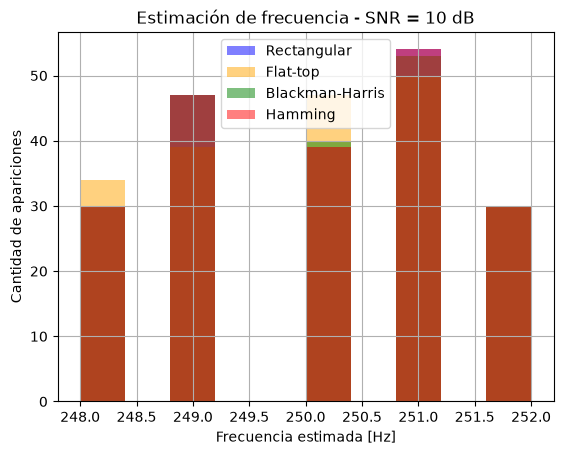

In [10]:
#Histograma de frecuencia para las 4 ventanas juntas con SNR=10 dB
plt.figure()
plt.hist(f1_rect_10db, alpha=0.5, color='b', label='Rectangular')
plt.hist(f1_flattop_10db, alpha=0.5, color='orange', label='Flat-top')
plt.hist(f1_bh_10db, alpha=0.5, color='green', label='Blackman-Harris')
plt.hist(f1_hamming_10db, alpha=0.5, color='red', label='Hamming')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de frecuencia - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

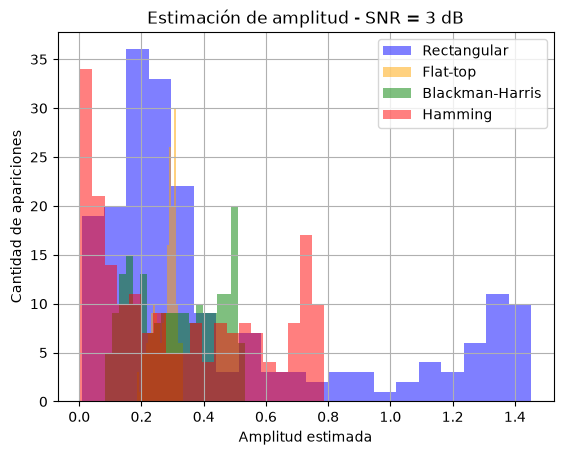

In [11]:
#Histograma de amplitud para las 4 ventanas juntas con SNR=3 dB
plt.figure()
plt.hist(a1_rect_3db, bins=20, alpha=0.5, color='b', label='Rectangular')
plt.hist(a1_flattop_3db, bins=20, alpha=0.5, color='orange', label='Flat-top')
plt.hist(a1_bh_3db, bins=20, alpha=0.5, color='green', label='Blackman-Harris')
plt.hist(a1_hamming_3db, bins=20, alpha=0.5, color='red', label='Hamming')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de amplitud - SNR = 3 dB')
plt.legend()
plt.grid()
plt.show()

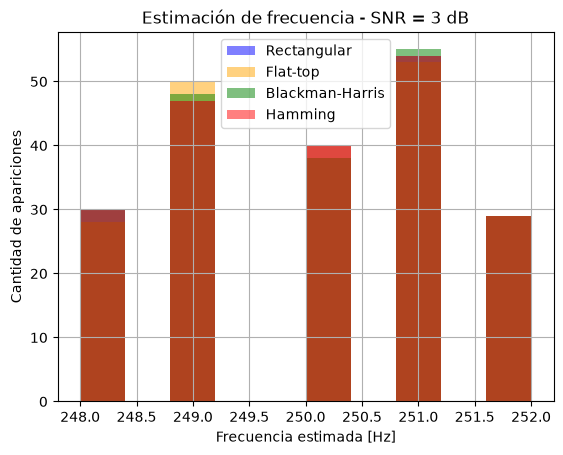

In [12]:
#Histograma de frecuencia para las 4 ventanas juntas con SNR=3 dB
plt.figure()
plt.hist(f1_rect_3db, alpha=0.5, color='b', label='Rectangular')
plt.hist(f1_flattop_3db, alpha=0.5, color='orange', label='Flat-top')
plt.hist(f1_bh_3db, alpha=0.5, color='green', label='Blackman-Harris')
plt.hist(f1_hamming_3db, alpha=0.5, color='red', label='Hamming')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de frecuencia - SNR = 3 dB')
plt.legend()
plt.grid()
plt.show()

**Histogramas de amplitud:** cada ventana concentra sus estimaciones en una zona distinta del eje X, sin solaparse demasiado entre sí. La ventana flat top forma la distribución más angosta y alta de las cuatro. La rectangular es la más ancha, ocupando gran parte del eje X. Blackman Harris y Hamming quedan en posiciones y anchos intermedios entre esas dos. Según lo visto antes sobre el ancho del lóbulo principal de cada ventana, esta diferencia de posición y ancho entre las cuatro distribuciones es consistente con lo esperado, ya q a mayor ancho de lóbulo, la distribución se corre más lejos del origen pero se vuelve más angosta, con menor varianza, y viceversa.

**Histogramas de frecuencia:** a diferencia de los de amplitud, acá las 4 ventanas caen casi exactamente sobre las mismas barras del histograma, superpuestas entre sí. Esto es coherente con lo explicado antes sobre el estimador $\hat{\Omega}_1$: como busca la ubicación del pico del espectro, y esa ubicación depende de dónde está la energía real de la señal y no tanto de qué ventana se usó, las 4 ventanas terminan estimando frecuencias similares. También se observa que las barras quedan agrupadas en valores enteros de Hz y se debe a q la resolución espectral es de 1 Hz, así que el estimador solo puede devolver frecuencias separadas por ese paso.

**Comparando SNR = 10 dB contra SNR = 3 dB:** tanto en amplitud como en frecuencia, los histogramas tienen una forma muy similar entre ambos SNR, sin diferencias visibles a simple vista.

Se muestran, para cada SNR, dos tablas con el sesgo y la varianza de cada estimador para las 4 ventanas

In [6]:
#Tabla para SNR=10 dB
print("Estimación de Amplitud - SNR = 10 dB")
print(f"{'Ventana':<18}{'s_a':>12}{'v_a':>12}")
print(f"{'Rectangular':<18}{sesgo_a1_rect_10db:>12.5f}{varianza_a1_rect_10db:>12.5f}")
print(f"{'Flat-top':<18}{sesgo_a1_flattop_10db:>12.5f}{varianza_a1_flattop_10db:>12.5f}")
print(f"{'Blackman-Harris':<18}{sesgo_a1_bh_10db:>12.5f}{varianza_a1_bh_10db:>12.5f}")
print(f"{'Hamming':<18}{sesgo_a1_hamming_10db:>12.5f}{varianza_a1_hamming_10db:>12.5f}")

print("\nEstimación de Frecuencia - SNR = 10 dB")
print(f"{'Ventana':<18}{'s_a':>12}{'v_a':>12}")
print(f"{'Rectangular':<18}{sesgo_f1_rect_10db:>12.5f}{varianza_f1_rect_10db:>12.5f}")
print(f"{'Flat-top':<18}{sesgo_f1_flattop_10db:>12.5f}{varianza_f1_flattop_10db:>12.5f}")
print(f"{'Blackman-Harris':<18}{sesgo_f1_bh_10db:>12.5f}{varianza_f1_bh_10db:>12.5f}")
print(f"{'Hamming':<18}{sesgo_f1_hamming_10db:>12.5f}{varianza_f1_hamming_10db:>12.5f}")

#Tabla para SNR=3 dB
print("\nEstimación de Amplitud - SNR = 3 dB")
print(f"{'Ventana':<18}{'s_a':>12}{'v_a':>12}")
print(f"{'Rectangular':<18}{sesgo_a1_rect_3db:>12.5f}{varianza_a1_rect_3db:>12.5f}")
print(f"{'Flat-top':<18}{sesgo_a1_flattop_3db:>12.5f}{varianza_a1_flattop_3db:>12.5f}")
print(f"{'Blackman-Harris':<18}{sesgo_a1_bh_3db:>12.5f}{varianza_a1_bh_3db:>12.5f}")
print(f"{'Hamming':<18}{sesgo_a1_hamming_3db:>12.5f}{varianza_a1_hamming_3db:>12.5f}")

print("\nEstimación de Frecuencia - SNR = 3 dB")
print(f"{'Ventana':<18}{'s_a':>12}{'v_a':>12}")
print(f"{'Rectangular':<18}{sesgo_f1_rect_3db:>12.5f}{varianza_f1_rect_3db:>12.5f}")
print(f"{'Flat-top':<18}{sesgo_f1_flattop_3db:>12.5f}{varianza_f1_flattop_3db:>12.5f}")
print(f"{'Blackman-Harris':<18}{sesgo_f1_bh_3db:>12.5f}{varianza_f1_bh_3db:>12.5f}")
print(f"{'Hamming':<18}{sesgo_f1_hamming_3db:>12.5f}{varianza_f1_hamming_3db:>12.5f}")

Estimación de Amplitud - SNR = 10 dB
Ventana                    s_a         v_a
Rectangular           -0.95066     0.18757
Flat-top              -1.13908     0.00100
Blackman-Harris       -1.10027     0.01718
Hamming               -1.09620     0.06915

Estimación de Frecuencia - SNR = 10 dB
Ventana                    s_a         v_a
Rectangular            0.00397     1.70377
Flat-top              -0.01603     1.72478
Blackman-Harris       -0.00103     1.69910
Hamming                0.00397     1.70377

Estimación de Amplitud - SNR = 3 dB
Ventana                    s_a         v_a
Rectangular           -0.94836     0.18770
Flat-top              -1.13876     0.00124
Blackman-Harris       -1.10017     0.01754
Hamming               -1.09414     0.06826

Estimación de Frecuencia - SNR = 3 dB
Ventana                    s_a         v_a
Rectangular           -0.00603     1.68437
Flat-top              -0.00603     1.65437
Blackman-Harris       -0.00603     1.69437
Hamming               -0.00603

Comparando SNR=10 dB contra SNR=3 dB, el sesgo y la varianza de cada ventana casi no cambian, a pesar de haber triplicado la potencia de ruido. Esto se explica porque hay dos fuentes de error distintas:

1. El corrimiento aleatorio de frecuencia $f_r$: hace que $\Omega_1$ no caiga exactamente en un bin.
2. El ruido $n_a(n)$ depende del SNR elegido.

Con estos niveles de SNR, el error q predomina es el del corrimiento de $f_r$, no el del ruido y es la explicacion de porqu, aunque se triplique la potencia de ruido, el sesgo y la varianza casi no se mueven ya que la mayor parte del error la genera la diferencia entre bines, no el ruido en sí.

También se observa q la ventana flat top tiene el sesgo de amplitud más grande por su lóbulo ancho pero la varianza de amplitud más chica y la rectangular tiene el comportamiento opuesto.

### Bonus: efecto del zero padding en el estimador de frecuencia

Zero-padding le agrega ceros al final de la señal antes de calcular la FFT. Por ejemplo, en vez de usar los $N=1000$ valores reales de la señal, se arma un vector de $N \cdot k$ muestras, donde las primeras $N$ son la señal real y el resto son ceros.

Es importante aclarar que relizr esto no agrega información nueva sobre la señal, pero sí aumenta la cantidad de bins de la FFT de salida, achicando la separación entre ellos. Lo cual es bueno ya que se puede leer el resultado con menos error de redondeo.

Como el estimador $\hat{\Omega}_1$ elige el bin más cercano al pico real, realizar zero padding le permite acercarse más a la frecuencia real. Por eso se espera que se reduzca la varianza del estimador de frecuencia. El sesgo, en cambio, no debería cambiar demasiado, porque depende de otras causas  como el efecto de la ventana.

Se aplicó un factor de $k=4$ para las 4 ventanas, con SNR = 10 dB, y se compara el sesgo y la varianza de $\hat{\Omega}_1$ con y sin zero padding.

In [13]:
# BONUS: efecto del zeropadding en el estimador de frecuencia, las 4 ventanas, SNR=10 dB
k_zp = 4 #factor de zeropaddin
N_zp = N * k_zp #nueva cantidad de puntos para la FFT

# vector de frecuencias para la FFT con zero padding
ff_vec_zp = np.fft.fftfreq(N_zp, 1/fs)
ff_vec_zp = ff_vec_zp[:N_zp//2]

#Rectangular con zero padding
YY_rect_zp = np.fft.fft(yy_rect_10db, n=N_zp, axis=0)
YY_mod_rect_zp = np.abs(YY_rect_zp[:N_zp//2, :]) / (N/2)
indice_max_rect_zp = np.argmax(YY_mod_rect_zp, axis=0)
f1_rect_zp = ff_vec_zp[indice_max_rect_zp]
sesgo_f1_rect_zp = np.mean(f1_rect_zp - f1_real)
varianza_f1_rect_zp = np.mean((f1_rect_zp - np.mean(f1_rect_zp))**2)

#Flattop con zero paddin
YY_flattop_zp = np.fft.fft(yy_flattop_10db, n=N_zp, axis=0)
YY_mod_flattop_zp = np.abs(YY_flattop_zp[:N_zp//2, :]) / (N/2)
indice_max_flattop_zp = np.argmax(YY_mod_flattop_zp, axis=0)
f1_flattop_zp = ff_vec_zp[indice_max_flattop_zp]
sesgo_f1_flattop_zp = np.mean(f1_flattop_zp - f1_real)
varianza_f1_flattop_zp = np.mean((f1_flattop_zp - np.mean(f1_flattop_zp))**2)

#Blackman Harris con zero padding
YY_bh_zp = np.fft.fft(yy_bh_10db, n=N_zp, axis=0)
YY_mod_bh_zp = np.abs(YY_bh_zp[:N_zp//2, :]) / (N/2)
indice_max_bh_zp = np.argmax(YY_mod_bh_zp, axis=0)
f1_bh_zp = ff_vec_zp[indice_max_bh_zp]
sesgo_f1_bh_zp = np.mean(f1_bh_zp - f1_real)
varianza_f1_bh_zp = np.mean((f1_bh_zp - np.mean(f1_bh_zp))**2)

#Hamming con zero padding
YY_hamming_zp = np.fft.fft(yy_hamming_10db, n=N_zp, axis=0)
YY_mod_hamming_zp = np.abs(YY_hamming_zp[:N_zp//2, :]) / (N/2)
indice_max_hamming_zp = np.argmax(YY_mod_hamming_zp, axis=0)
f1_hamming_zp = ff_vec_zp[indice_max_hamming_zp]
sesgo_f1_hamming_zp = np.mean(f1_hamming_zp - f1_real)
varianza_f1_hamming_zp = np.mean((f1_hamming_zp - np.mean(f1_hamming_zp))**2)

Se compara el sesgo y la varianza del estimador de frecuencia $\hat{\Omega}_1$, con y sin zero-padding, para las 4 ventanas.

In [14]:
# Tabla comparativa sin zero-padding vs con zero-padding, para las 4 ventanas
print("\nEstimador de frecuencia - SNR = 10 dB - Efecto del zero-padding (k=4)")
print(f"{'Ventana':<18}{'s_a sin ZP':>14}{'v_a sin ZP':>14}{'s_a con ZP':>14}{'v_a con ZP':>14}")
print(f"{'Rectangular':<18}{sesgo_f1_rect_10db:>14.5f}{varianza_f1_rect_10db:>14.5f}{sesgo_f1_rect_zp:>14.5f}{varianza_f1_rect_zp:>14.5f}")
print(f"{'Flat-top':<18}{sesgo_f1_flattop_10db:>14.5f}{varianza_f1_flattop_10db:>14.5f}{sesgo_f1_flattop_zp:>14.5f}{varianza_f1_flattop_zp:>14.5f}")
print(f"{'Blackman-Harris':<18}{sesgo_f1_bh_10db:>14.5f}{varianza_f1_bh_10db:>14.5f}{sesgo_f1_bh_zp:>14.5f}{varianza_f1_bh_zp:>14.5f}")
print(f"{'Hamming':<18}{sesgo_f1_hamming_10db:>14.5f}{varianza_f1_hamming_10db:>14.5f}{sesgo_f1_hamming_zp:>14.5f}{varianza_f1_hamming_zp:>14.5f}")


Estimador de frecuencia - SNR = 10 dB - Efecto del zero-padding (k=4)
Ventana               s_a sin ZP    v_a sin ZP    s_a con ZP    v_a con ZP
Rectangular              0.00397       1.70377      -0.00103       1.47910
Flat-top                -0.01603       1.72478      -0.04853       1.64469
Blackman-Harris         -0.00103       1.69910      -0.00103       1.48598
Hamming                  0.00397       1.70377      -0.00103       1.48160


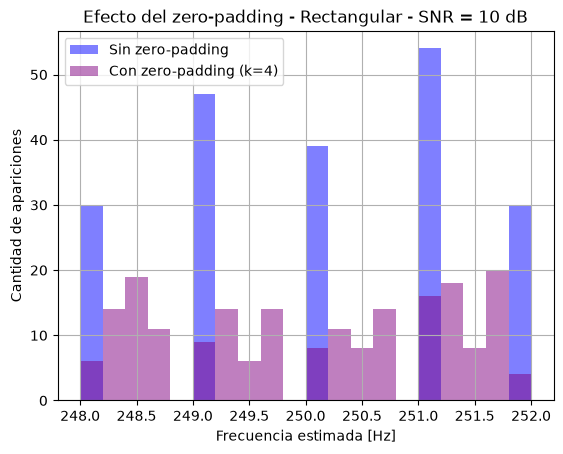

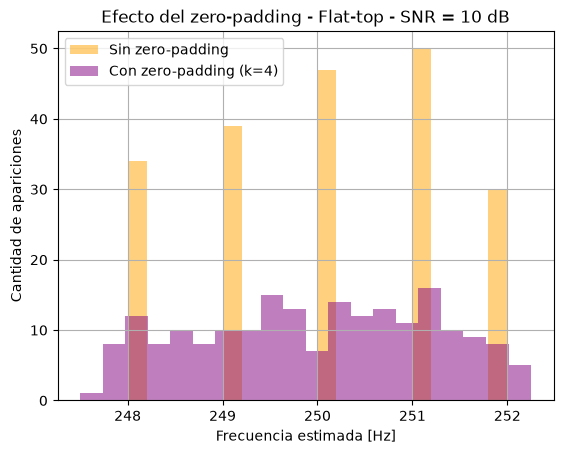

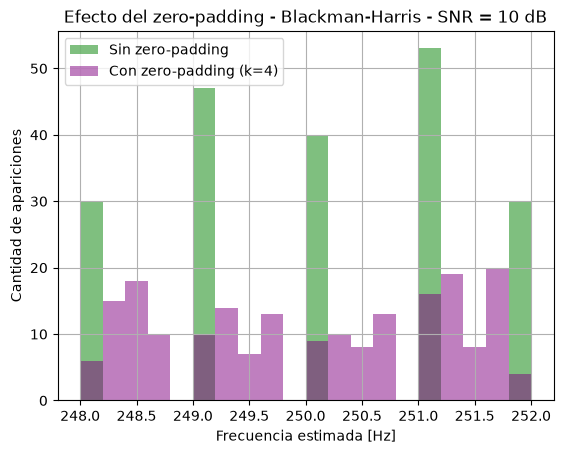

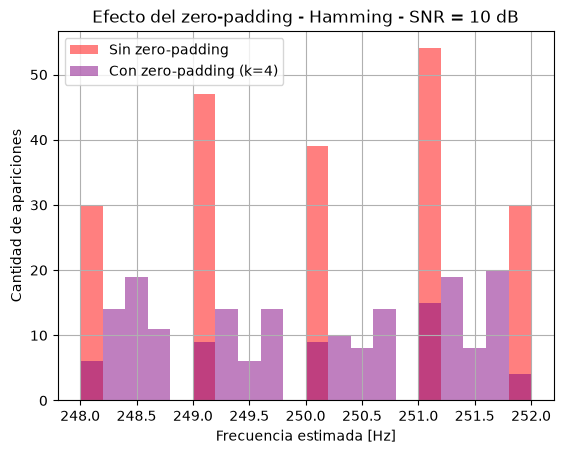

In [15]:
# Gráfico de la ventana eectangular, sin ZP y con ZP
plt.figure()
plt.hist(f1_rect_10db, bins=20, alpha=0.5, color='b', label='Sin zero-padding')
plt.hist(f1_rect_zp, bins=20, alpha=0.5, color='purple', label='Con zero-padding (k=4)')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Efecto del zero-padding - Rectangular - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

# Gráfico de Flattop, sin ZP y con ZP
plt.figure()
plt.hist(f1_flattop_10db, bins=20, alpha=0.5, color='orange', label='Sin zero-padding')
plt.hist(f1_flattop_zp, bins=20, alpha=0.5, color='purple', label='Con zero-padding (k=4)')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Efecto del zero-padding - Flat-top - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

#Gráfico de Blackman Harris, sin ZP y con ZP
plt.figure()
plt.hist(f1_bh_10db, bins=20, alpha=0.5, color= 'green', label='Sin zero-padding')
plt.hist(f1_bh_zp, bins=20, alpha=0.5, color= 'purple', label='Con zero-padding (k=4)')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Efecto del zero-padding - Blackman-Harris - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

#Gráfico de Hamming, sin ZP y con ZP
plt.figure()
plt.hist(f1_hamming_10db, bins=20, alpha=0.5, color='red', label='Sin zero-padding')
plt.hist(f1_hamming_zp, bins=20, alpha=0.5, color='purple', label='Con zero-padding (k=4)')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Efecto del zero-padding - Hamming - SNR = 10 dB')
plt.legend()
plt.grid()
plt.show()

En la tabla comparativa se observa que, para las 4 ventanas, la varianza del estimador de frecuencia baja al aplicar zero padding, mientras que el sesgo se mantiene en valores similares, algunos mejoran muy poquito. Esto confirma que el zero padding reduce el error de redondeo pero no corrige el sesgo, que depende de otras causas.

En los histogramas comparativos se ve claramente lo mismom sin zero padding, las estimaciones de frecuencia quedan agrupadas únicamente en valores enteros de Hz, porque la resolución espectral solo permite esos valores. Con zero padding, las estimaciones se distribuyen de forma mucho más continua a lo largo del eje, acercándose más al valor real de cada realización.

igualmente esta mejora tiene un límite ya que a partir de cierto $k$, la varianza deja de bajar porque el ruido y el  desparramo pasan a ser la fuente de error dominante.

## Conclusión

Vimos que no existe una ventana "perfecta". Segun que tan ancho sea su lobulo principal, cada una prioriza distinto entre precisión (sesgo bajo) y estabilidad (varianza baja). La rectangular y la flat top son exactamente opuestas, mientras que Blackman Harris y Hamming quedan en un punto intermedio.
Ademas notamos que el estimador de amplitud es mucho más sensible a la ventana elegida a diferencia del estimador de frecuencia, ya que depende sobre todo de dónde está la energía real de la señal.
Uno cree que el ruido es la causa de eror mas grande pero, el nivel de SNR no siempre es la fuente de error dominante en este experimento, el corrimiento aleatorio de frecuencia $f_r$ (independiente del ruido) explicó la mayor parte del sesgo y la varianza observados, tanto en SNR=10dB como en SNR=3dB.
El zero-padding mejora la precisión de la estimación de frecuencia, pero solo hasta cierto punto, reduciendo el error de redondeo, pero sin corregir el sesgo ni eliminar el error que aporta el ruido o el desparramo espectral de cada ventana.